## PROJECT 5: Convolutional Neural Network (CNN) - Image Classification
### Techniques: Convolution, Pooling, Filters, Feature Maps

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("Loading CIFAR-10 dataset...")
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 739s 4us/step


In [3]:
# Normalize pixel values
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [4]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [5]:
print(f"Training samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")
print(f"Image shape: {x_train.shape[1:]}")

Training samples: 50000
Test samples: 10000
Image shape: (32, 32, 3)



Visualizing sample images...
Sample images saved as 'cifar10_samples.png'


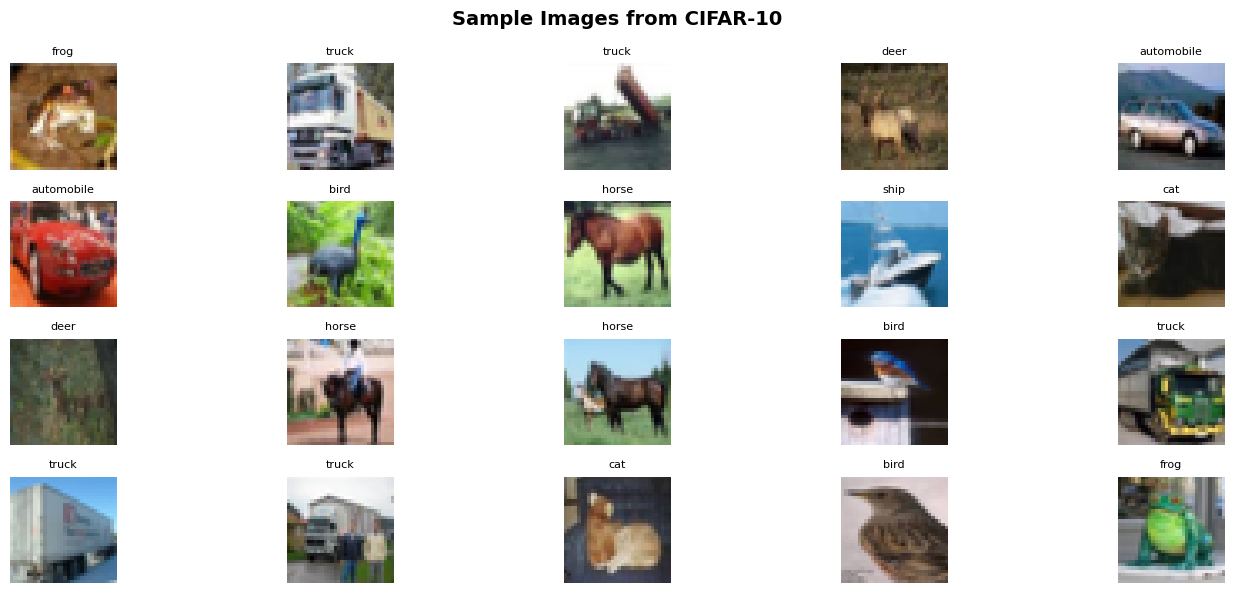

In [6]:
# Visualize some samples
print("\nVisualizing sample images...")
plt.figure(figsize=(15, 6))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=8)
    plt.axis('off')
plt.suptitle('Sample Images from CIFAR-10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=150)
print("Sample images saved as 'cifar10_samples.png'")

In [7]:
# Build CNN model
print("\nBuilding CNN architecture...")
cnn_model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


Building CNN architecture...


C:\Users\Shridhar\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
print("\nModel Architecture:")
cnn_model.summary()


Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 128)                 │             5

 Total params: 404,778 (1.54 MB)

 Trainable params: 403,882 (1.54 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# Train the model
print("\nTraining CNN model...")
history = cnn_model.fit(
    x_train[:10000], y_train[:10000],
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Training CNN model...
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 325s 3s/step - accuracy: 0.3004 - loss: 2.2658 - val_accuracy: 0.0965 - val_loss: 4.8341
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 347s 3s/step - accuracy: 0.4100 - loss: 1.7159 - val_accuracy: 0.1435 - val_loss: 3.0534
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 446s 3s/step - accuracy: 0.4759 - loss: 1.4904 - val_accuracy: 0.2585 - val_loss: 2.2319
Epoch 4/20
 50/125 ━━━━━━━━━━━━━━━━━━━━ 2:33 2s/step - accuracy: 0.5164 - loss: 1.3287

In [ ]:
# Plot training history
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
plt.title('CNN Training - Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation', linewidth=2)
plt.title('CNN Training - Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

In [ ]:
plt.tight_layout()
plt.savefig('cnn_training_history.png', dpi=150)
print("\nTraining history saved as 'cnn_training_history.png'")

In [ ]:
# Evaluate on test set
print("\nEvaluating model...")
test_loss, test_acc = cnn_model.evaluate(x_test[:1000], y_test[:1000], verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

In [ ]:
# Make predictions and visualize
print("\nMaking predictions on test images...")
predictions = cnn_model.predict(x_test[:20])

plt.figure(figsize=(16, 8))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(x_test[i])
    
    pred_class = np.argmax(predictions[i])
    true_class = y_test[i][0]
    confidence = predictions[i][pred_class] * 100
    
    color = 'green' if pred_class == true_class else 'red'
    plt.title(f"Pred: {class_names[pred_class]}\nTrue: {class_names[true_class]}\n{confidence:.1f}%",
             color=color, fontsize=8)
    plt.axis('off')

plt.suptitle('CNN Predictions (Green=Correct, Red=Wrong)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_predictions.png', dpi=150)
print("Predictions saved as 'cnn_predictions.png'")

In [ ]:
print("\n" + "="*60)
print("CNN COMPONENTS EXPLAINED:")
print("="*60)
print("Conv2D: Applies filters to detect features (edges, textures)")
print("MaxPooling2D: Reduces spatial dimensions, keeps important features")
print("BatchNormalization: Normalizes activations, speeds up training")
print("Dropout: Prevents overfitting by randomly dropping neurons")
print("Flatten: Converts 2D feature maps to 1D for dense layers")
print("Dense: Fully connected layers for final classification")
print("\n✓ CNNs are powerful for image recognition tasks!")